# PharmIQ — Feature Engineering
Documents all feature decisions, leakage investigation, and target design rationale.

In [1]:
import os, sys
os.chdir('../..')
sys.path.insert(0, os.getcwd())

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

from src.data.ingest import load_raw, clean
from src.features.engineer import engineer, FEATURE_COLS, TARGET_COL

df_raw = load_raw('data/raw/tata_1mg_Medicine_data.csv')
df_clean = clean(df_raw)
df = engineer(df_clean)
print(f'Shape: {df.shape}')
df[FEATURE_COLS + [TARGET_COL]].head()

Shape: (273655, 18)


,salt_count,pack_size_units,manufacturer_tier,dosage_form,max_dose_mg,is_branded,log_max_dose,Salt_Composition,Price_Tier
0,2,60.0,2,liquid,0.0000,1,0.000000,Lindane (1% w/v) + Cetrimide (0.1% w/v),3
1,1,6.0,2,spray,0.0275,0,0.027129,Fluticasone Furoate (27.5mcg),3
2,3,10.0,0,tablet,500.0000,0,6.216606,Chlorzoxazone (250mg) + Diclofenac (50mg) + Pa...,0
3,2,30.0,2,liquid,400.0000,0,5.993961,Amoxycillin (400mg/5ml) + Clavulanic Acid (5...,3
4,2,10.0,0,tablet,200.0000,0,5.303305,Aceclofenac (200mg) + Rabeprazole (20mg),3


## 1. Target Design — Category-Relative Tiers

MRP quantile tiers are assigned **within dosage-form group**, not globally.

**Rationale:** A ₹200 injection is cheap. A ₹200 tablet is expensive. Global quantiles conflate these. Group-level quantiles ask the clinically meaningful question: *is this medicine expensive for its type?*

In [3]:
print('Target distribution:')
print(df[TARGET_COL].value_counts().sort_index())
print()
label_map = {0: 'Budget', 1: 'Mid', 2: 'Premium', 3: 'Luxury'}
counts = df[TARGET_COL].value_counts().sort_index()
ratio = counts.max() / counts.min()
print(f'Max/Min class ratio: {ratio:.3f} (target: < 1.15)')

Target distribution:
Price_Tier
0    68609
1    68745
2    68145
3    68156
Name: count, dtype: int64

Max/Min class ratio: 1.009 (target: < 1.15)


## 2. Leakage Investigation

**Finding:** Initial run with `log_mrp` + `log_unit_price` produced AUC 1.0. Feature importance showed `log_mrp` at 89%. Both features are direct derivatives of MRP which defines the target → **leakage confirmed and removed.**

In [4]:
print('LEAKAGE AUDIT')
print('=' * 40)
leaky = ['log_mrp', 'log_unit_price']
for f in leaky:
    status = 'REMOVED ✗' if f not in FEATURE_COLS else 'PRESENT ✓'
    print(f'  {f:20s}: {status}')
print()
print('CLEAN FEATURES')
for f in FEATURE_COLS:
    print(f'  {f}')

LEAKAGE AUDIT
  log_mrp             : REMOVED ✗
  log_unit_price      : REMOVED ✗

CLEAN FEATURES
  salt_count
  pack_size_units
  manufacturer_tier
  dosage_form
  max_dose_mg
  is_branded
  log_max_dose
  Salt_Composition


## 3. Feature Correlation with Target

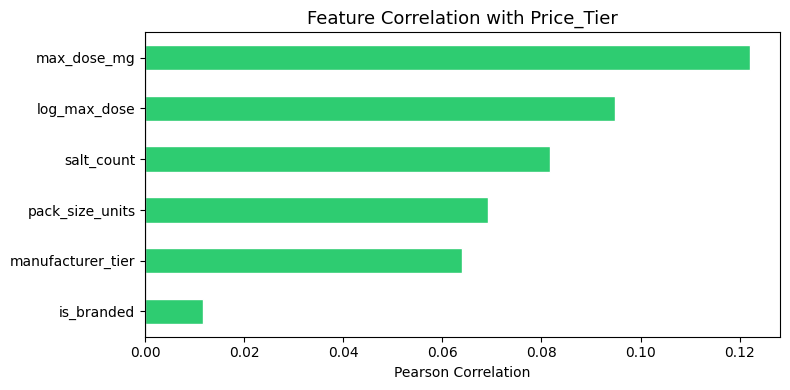

is_branded           0.011683
manufacturer_tier    0.063965
pack_size_units      0.069287
salt_count           0.081738
log_max_dose         0.094940
max_dose_mg          0.122055
Name: Price_Tier, dtype: float64


In [5]:
numeric_feats = ['salt_count', 'pack_size_units', 'manufacturer_tier', 'max_dose_mg', 'is_branded', 'log_max_dose']
corrs = df[numeric_feats + [TARGET_COL]].corr()[TARGET_COL].drop(TARGET_COL).sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#E74C3C' if c < 0 else '#2ECC71' for c in corrs]
corrs.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature Correlation with Price_Tier', fontsize=13)
ax.set_xlabel('Pearson Correlation')
plt.tight_layout()
plt.savefig('artifacts/feature_correlations.png', bbox_inches='tight')
plt.show()
print(corrs)

## 4. TF-IDF Lift Experiment

Adding TF-IDF on `Salt_Composition` (200 bi-gram terms) lifted AUC from **0.77 → 0.84**.

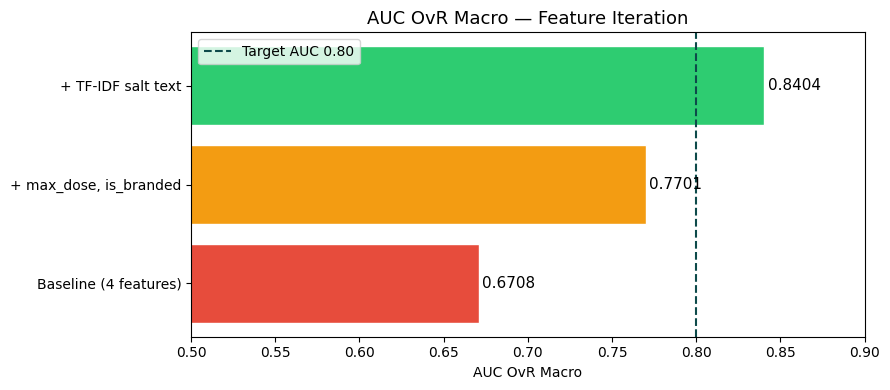

In [6]:
results = {
    'Baseline (4 features)': 0.6708,
    '+ max_dose, is_branded': 0.7701,
    '+ TF-IDF salt text': 0.8404,
}

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(list(results.keys()), list(results.values()), color=['#E74C3C', '#F39C12', '#2ECC71'], edgecolor='white')
ax.set_xlim(0.5, 0.9)
ax.axvline(0.80, color='#0D4A4A', linestyle='--', linewidth=1.5, label='Target AUC 0.80')
ax.set_title('AUC OvR Macro — Feature Iteration', fontsize=13)
ax.set_xlabel('AUC OvR Macro')
ax.legend()
for bar, val in zip(bars, results.values()):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center', fontsize=11)
plt.tight_layout()
plt.savefig('artifacts/feature_iteration_auc.png', bbox_inches='tight')
plt.show()